In [97]:
import os
import json
import glob
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import defaultdict, Counter
from skimage import exposure
from skimage import data, img_as_float
import matplotlib
import numpy as np
matplotlib.rcParams['font.size'] = 8
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import skimage 


In [44]:

BASE_DIR = Path(r"c:/Users/ANING/Downloads/54816/54816")

DIR_24   = BASE_DIR / "24_chromosomes_object"
DIR_SNGL = BASE_DIR / "single_chromosomes_object"

ANN_24   = DIR_24 / "annotations"
IMG_24   = DIR_24 / "JEPG"        

ANN_SNGL = DIR_SNGL / "anntations" 
IMG_SNGL = DIR_SNGL / "JEPG"

TRAIN_TXT = BASE_DIR / "train.txt"
TEST_TXT  = BASE_DIR / "test.txt"
DIFF_TXT  = BASE_DIR / "diff_image.txt"

In [98]:
import random

all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))
all_img_sngl = sorted(IMG_SNGL.glob("*.jpg")) + sorted(IMG_SNGL.glob("*.JPG"))


SUBSET_SIZE = 100
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24
img_sngl = random.sample(all_img_sngl, min(SUBSET_SIZE, len(all_img_sngl))) if SUBSET_SIZE else all_img_sngl

print(f"24-chr  subset : {len(img_24)}  / {len(all_img_24)}  total")
print(f"Single  subset : {len(img_sngl)} / {len(all_img_sngl)} total")

24-chr  subset : 100  / 10000  total
Single  subset : 100 / 4000 total


2.2 Dataset Exploration

 Inspect image dimensions

 Analyze RGB channel distributions

 Compare grayscale vs single-channel segmentation

 Visualize sample images

In [107]:
img_raw = skimage.io.imread(img_24[0],as_gray=True)

print("Shape :", img_raw.shape)   
print("dtype :", img_raw.dtype)
print("Range :", img_raw.min().round(3), "–", img_raw.max().round(3))

Shape : (668, 527)
dtype : float64
Range : 0.012 – 1.0


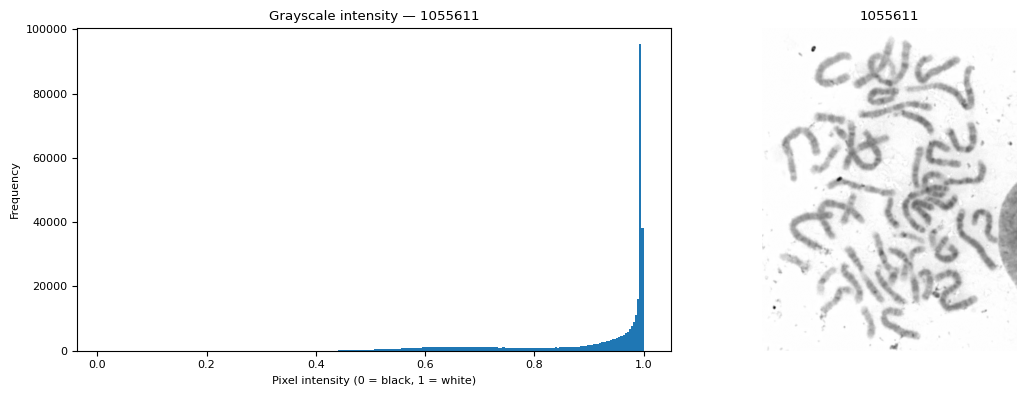

In [124]:
img = skimage.filters.gaussian(img_raw,0.3,preserve_range=True)
img = np.clip(img, 0, 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


axes[0].hist(img.ravel(), bins=256, )
axes[0].set_title(f"Grayscale intensity — {img_24[0].stem}")
axes[0].set_xlabel("Pixel intensity (0 = black, 1 = white)")
axes[0].set_ylabel("Frequency")


axes[1].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(img_24[0].stem)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [101]:
def plot_img_and_hist(image, axes, bins=256):
    """Plot an image along with its histogram and cumulative histogram."""
    image = img_as_float(image)
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    # Display image
    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    # Display histogram
    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Pixel intensity')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    # Display cumulative distribution
    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf


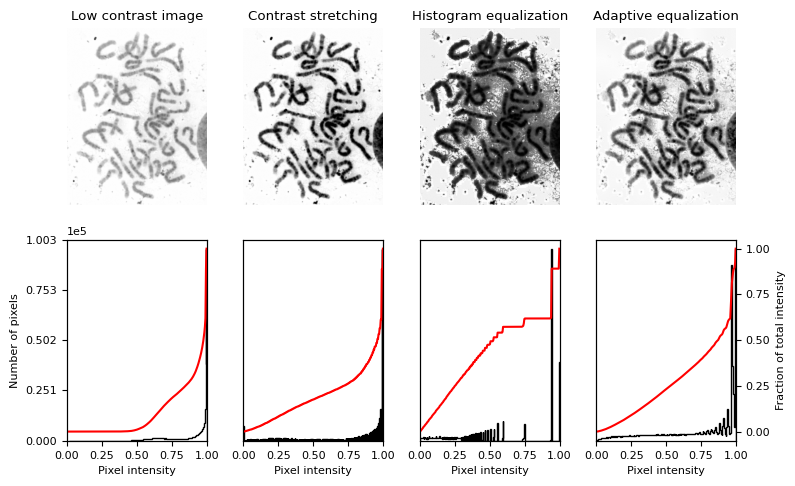

In [ ]:
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Equalization
img_eq = exposure.equalize_hist(img)

# Adaptive Equalization
img_adapteq = exposure.equalize_adapthist(img, clip_limit=0.03)

# Display results
fig = plt.figure(figsize=(8, 5))
axes = np.zeros((2, 4), dtype=object)
axes[0, 0] = fig.add_subplot(2, 4, 1)
for i in range(1, 4):
    axes[0, i] = fig.add_subplot(2, 4, 1 + i, sharex=axes[0, 0], sharey=axes[0, 0])
for i in range(0, 4):
    axes[1, i] = fig.add_subplot(2, 4, 5 + i)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img, axes[:, 0])
ax_img.set_title('Low contrast image')

y_min, y_max = ax_hist.get_ylim()
ax_hist.set_ylabel('Number of pixels')
ax_hist.set_yticks(np.linspace(0, y_max, 5))

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescale, axes[:, 1])
ax_img.set_title('Contrast stretching')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[:, 2])
ax_img.set_title('Histogram equalization')

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[:, 3])
ax_img.set_title('Adaptive equalization')

ax_cdf.set_ylabel('Fraction of total intensity')
ax_cdf.set_yticks(np.linspace(0, 1, 5))

# prevent overlap of y-axis labels
fig.tight_layout()
plt.show()

In [126]:
gray_images = [skimage.io.imread(p, as_gray=True) for p in img_24]

In [46]:
records = []
for path, gray in zip(img_24, gray_images):
    flat = gray.ravel()
    p5, p95 = np.percentile(flat, [5, 95])
    records.append({
        "filename"     : path.stem,
        "mean"         : flat.mean(),
        "std"          : flat.std(),
        "min"          : flat.min(),
        "max"          : flat.max(),
        "p5"           : p5,
        "p95"          : p95,
        "dynamic_range": p95 - p5,
    })

df_stats = pd.DataFrame(records)
print(df_stats[["mean", "std", "p5", "p95", "dynamic_range"]].describe().round(3))
display(df_stats.sort_values("dynamic_range").head(5)[["filename", "mean", "std", "dynamic_range"]]
        .rename(columns={"dynamic_range": "dynamic_range (lowest contrast)"}))

          mean      std       p5      p95  dynamic_range
count  100.000  100.000  100.000  100.000        100.000
mean     0.883    0.163    0.487    0.979          0.493
std      0.052    0.039    0.099    0.042          0.104
min      0.701    0.064    0.275    0.780          0.188
25%      0.856    0.132    0.416    0.988          0.412
50%      0.898    0.164    0.480    0.996          0.492
75%      0.916    0.189    0.557    1.000          0.565
max      0.968    0.278    0.812    1.000          0.725


,filename,mean,std,dynamic_range (lowest contrast)
54,1053113,0.966091,0.064018,0.188235
51,1052232,0.955885,0.099931,0.309804
71,unknow018,0.901653,0.098478,0.313725
40,1051051,0.925142,0.099063,0.317647
36,1054492,0.826237,0.099980,0.333333


C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\531839873.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


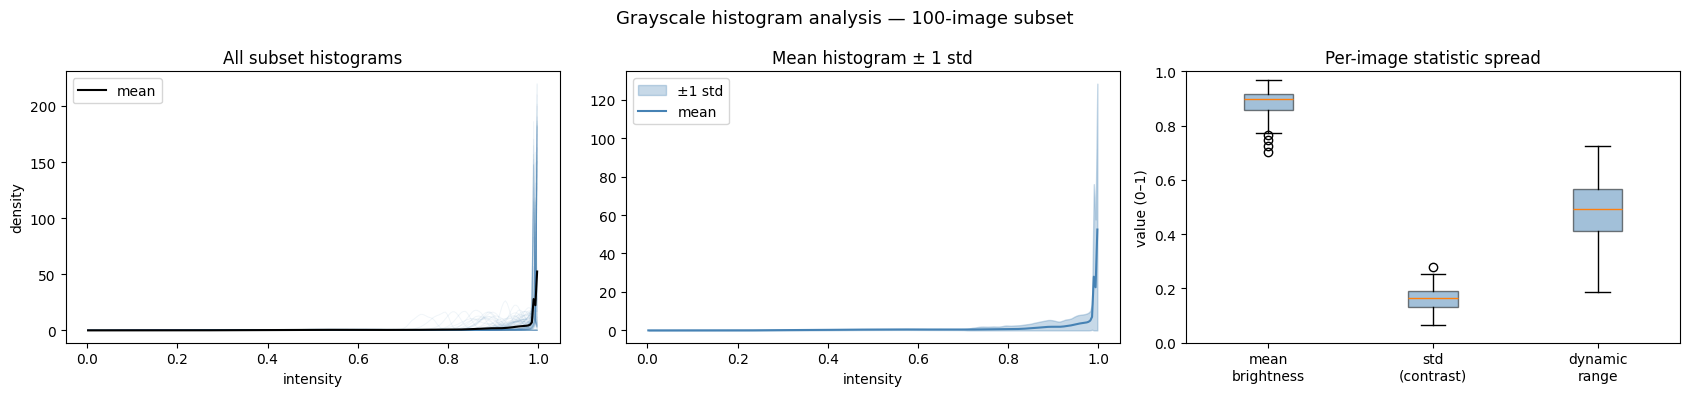

In [ ]:
BINS = 256
bin_edges = np.linspace(0, 1, BINS + 1)
bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2


all_hists = np.stack([
    np.histogram(g.ravel(), bins=bin_edges, density=True)[0]
    for g in gray_images
])

mean_hist = all_hists.mean(axis=0)
std_hist  = all_hists.std(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

for h in all_hists:
    axes[0].plot(bin_centres, h, color="steelblue", alpha=0.08, linewidth=0.7)
axes[0].plot(bin_centres, mean_hist, color="black", linewidth=1.5, label="mean")
axes[0].set_title("All subset histograms")
axes[0].set_xlabel("intensity")
axes[0].set_ylabel("density")
axes[0].legend()

# — Middle: mean ± 1 std band —
axes[1].fill_between(bin_centres,
                     np.maximum(mean_hist - std_hist, 0),
                     mean_hist + std_hist,
                     alpha=0.3, color="steelblue", label="±1 std")
axes[1].plot(bin_centres, mean_hist, color="steelblue", linewidth=1.5, label="mean")
axes[1].set_title("Mean histogram ± 1 std")
axes[1].set_xlabel("intensity")
axes[1].legend()


axes[2].boxplot(
    [df_stats["mean"], df_stats["std"], df_stats["dynamic_range"]],
    labels=["mean\nbrightness", "std\n(contrast)", "dynamic\nrange"],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
)
axes[2].set_ylabel("value (0–1)")
axes[2].set_title("Per-image statistic spread")
axes[2].set_ylim(0, 1)

plt.suptitle("Grayscale histogram analysis — 100-image subset", fontsize=13)
plt.tight_layout()
plt.show()

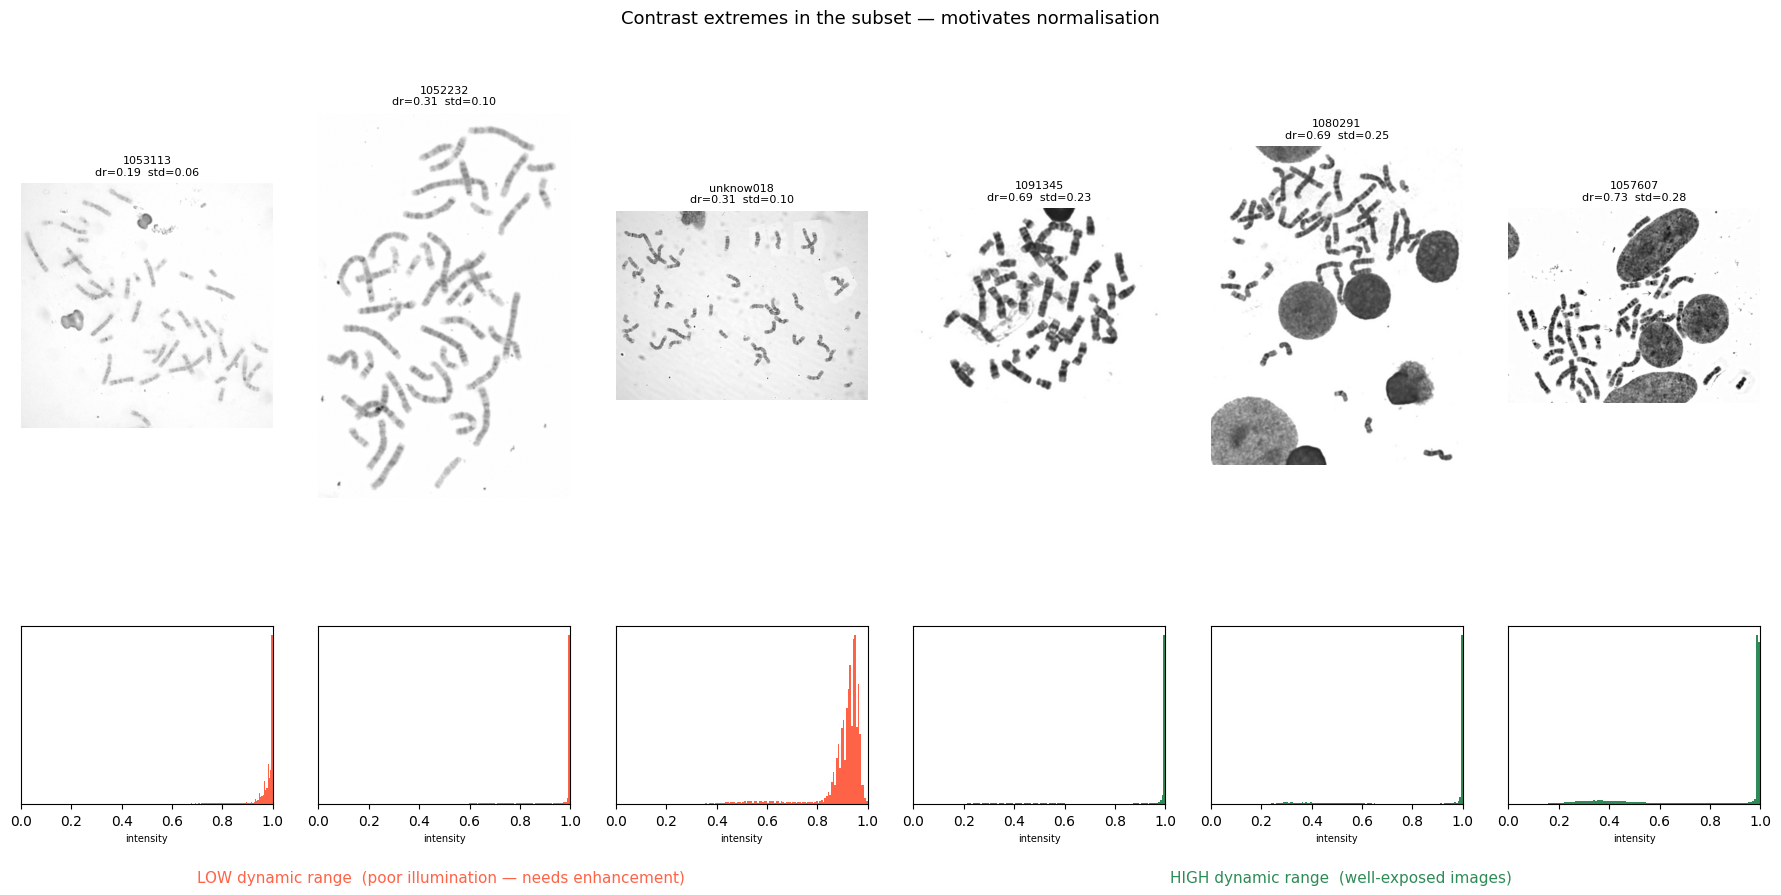

In [ ]:
sorted_df = df_stats.sort_values("dynamic_range")
low_idx   = sorted_df.index[:3].tolist()   
high_idx  = sorted_df.index[-3:].tolist()  

fig, axes = plt.subplots(3, 6, figsize=(18, 9),
                         gridspec_kw={"height_ratios": [3, 1, 0.1]})

for col, idx in enumerate(low_idx + high_idx):
    gray = gray_images[idx]
    flat = gray.ravel()
    row_label = "LOW contrast" if col < 3 else "HIGH contrast"
    color     = "tomato"       if col < 3 else "seagreen"

    axes[0, col].imshow(gray, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(
        f"{img_24[idx].stem}\ndr={df_stats.loc[idx,'dynamic_range']:.2f}  "
        f"std={df_stats.loc[idx,'std']:.2f}",
        fontsize=8
    )
    axes[0, col].axis("off")


    axes[1, col].hist(flat, bins=128, color=color, density=True)
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("intensity", fontsize=7)


    axes[2, col].axis("off")


fig.text(0.25, 0.01, "LOW dynamic range  (poor illumination — needs enhancement)",
         ha="center", color="tomato", fontsize=11)
fig.text(0.75, 0.01, "HIGH dynamic range  (well-exposed images)",
         ha="center", color="seagreen", fontsize=11)

plt.suptitle("Contrast extremes in the subset — motivates normalisation", fontsize=13)
plt.tight_layout()
plt.show()

## 2.3 Contrast Enhancement

Pipeline: **white top-hat** (removes slow background gradient) → **CLAHE** (local contrast equalisation).

- `TOPHAT_RADIUS` should exceed the widest chromosome (~30–50 px).  
- `CLAHE_CLIP` controls noise amplification — lower is safer.

In [ ]:
from skimage import exposure
from skimage.morphology import disk, white_tophat

TOPHAT_RADIUS = 40
CLAHE_CLIP    = 0.02
CLAHE_TILES   = (8, 8)

def enhance_contrast(gray_img,
                     tophat_radius=TOPHAT_RADIUS,
                     clahe_clip=CLAHE_CLIP,
                     clahe_tiles=CLAHE_TILES):
    """White top-hat background correction followed by CLAHE."""
    tophat   = white_tophat(gray_img, disk(tophat_radius))
    enhanced = exposure.equalize_adapthist(
        tophat, kernel_size=clahe_tiles, clip_limit=clahe_clip
    )
    return enhanced

# ── 4-way comparison on one image ────────────────────────────────────────────
sample_raw = gray_images[0]
imgs   = [sample_raw,
          exposure.equalize_hist(sample_raw),
          enhance_contrast(sample_raw, tophat_radius=1),  # CLAHE only
          enhance_contrast(sample_raw)]
titles = ["Original", "Global HE", "CLAHE only", "Top-hat + CLAHE"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9),
                         gridspec_kw={"height_ratios": [3, 1]})
for ax_img, ax_hist, im, title in zip(axes[0], axes[1], imgs, titles):
    ax_img.imshow(im, cmap="gray", vmin=0, vmax=1)
    ax_img.set_title(title, fontsize=11)
    ax_img.axis("off")
    ax_hist.hist(im.ravel(), bins=200, color="gray", density=True)
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])
    ax_hist.set_xlabel("intensity")
plt.suptitle("Contrast enhancement comparison", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
enhanced_images = [enhance_contrast(g) for g in gray_images]

print(f"Enhanced {len(enhanced_images)} images")
print(f"dtype : {enhanced_images[0].dtype}  "
      f"range : {enhanced_images[0].min():.3f}–{enhanced_images[0].max():.3f}")

In [ ]:
from skimage.filters import gaussian, median
from skimage.morphology import disk
from skimage.restoration import denoise_bilateral
from skimage.metrics import structural_similarity as ssim

work_images = enhanced_images if "enhanced_images" in globals() else gray_images


GAUSS_SIGMA     = 1.0   
MEDIAN_RADIUS   = 2     
BILATERAL_SC    = 0.05  
BILATERAL_SS    = 2.0  

sample = work_images[0]

gauss    = gaussian(sample,           sigma=GAUSS_SIGMA)
med      = median(sample,             footprint=disk(MEDIAN_RADIUS))
bilat    = denoise_bilateral(sample,  sigma_color=BILATERAL_SC,
                                      sigma_spatial=BILATERAL_SS,
                                      channel_axis=None)


ssim_g = ssim(sample, gauss, data_range=1.0)
ssim_m = ssim(sample, med,   data_range=1.0)
ssim_b = ssim(sample, bilat, data_range=1.0)


from skimage.filters import sobel
edge_orig  = sobel(sample).mean()
edge_gauss = sobel(gauss).mean()
edge_med   = sobel(med).mean()
edge_bilat = sobel(bilat).mean()


for name, s, e in [("Original",  1.0,    edge_orig),
                   ("Gaussian",  ssim_g, edge_gauss),
                   ("Median",    ssim_m, edge_med),
                   ("Bilateral", ssim_b, edge_bilat)]:
    print(f"{name:<12} {s:>6.4f}  {e:>13.5f}  {e/edge_orig:>12.1%}")

Filter         SSIM  Edge strength  Edge retained
--------------------------------------------------
Original     1.0000        0.02171        100.0%
Gaussian     0.9849        0.01913         88.1%
Median       0.9837        0.01928         88.8%
Bilateral    0.9228        0.01784         82.2%


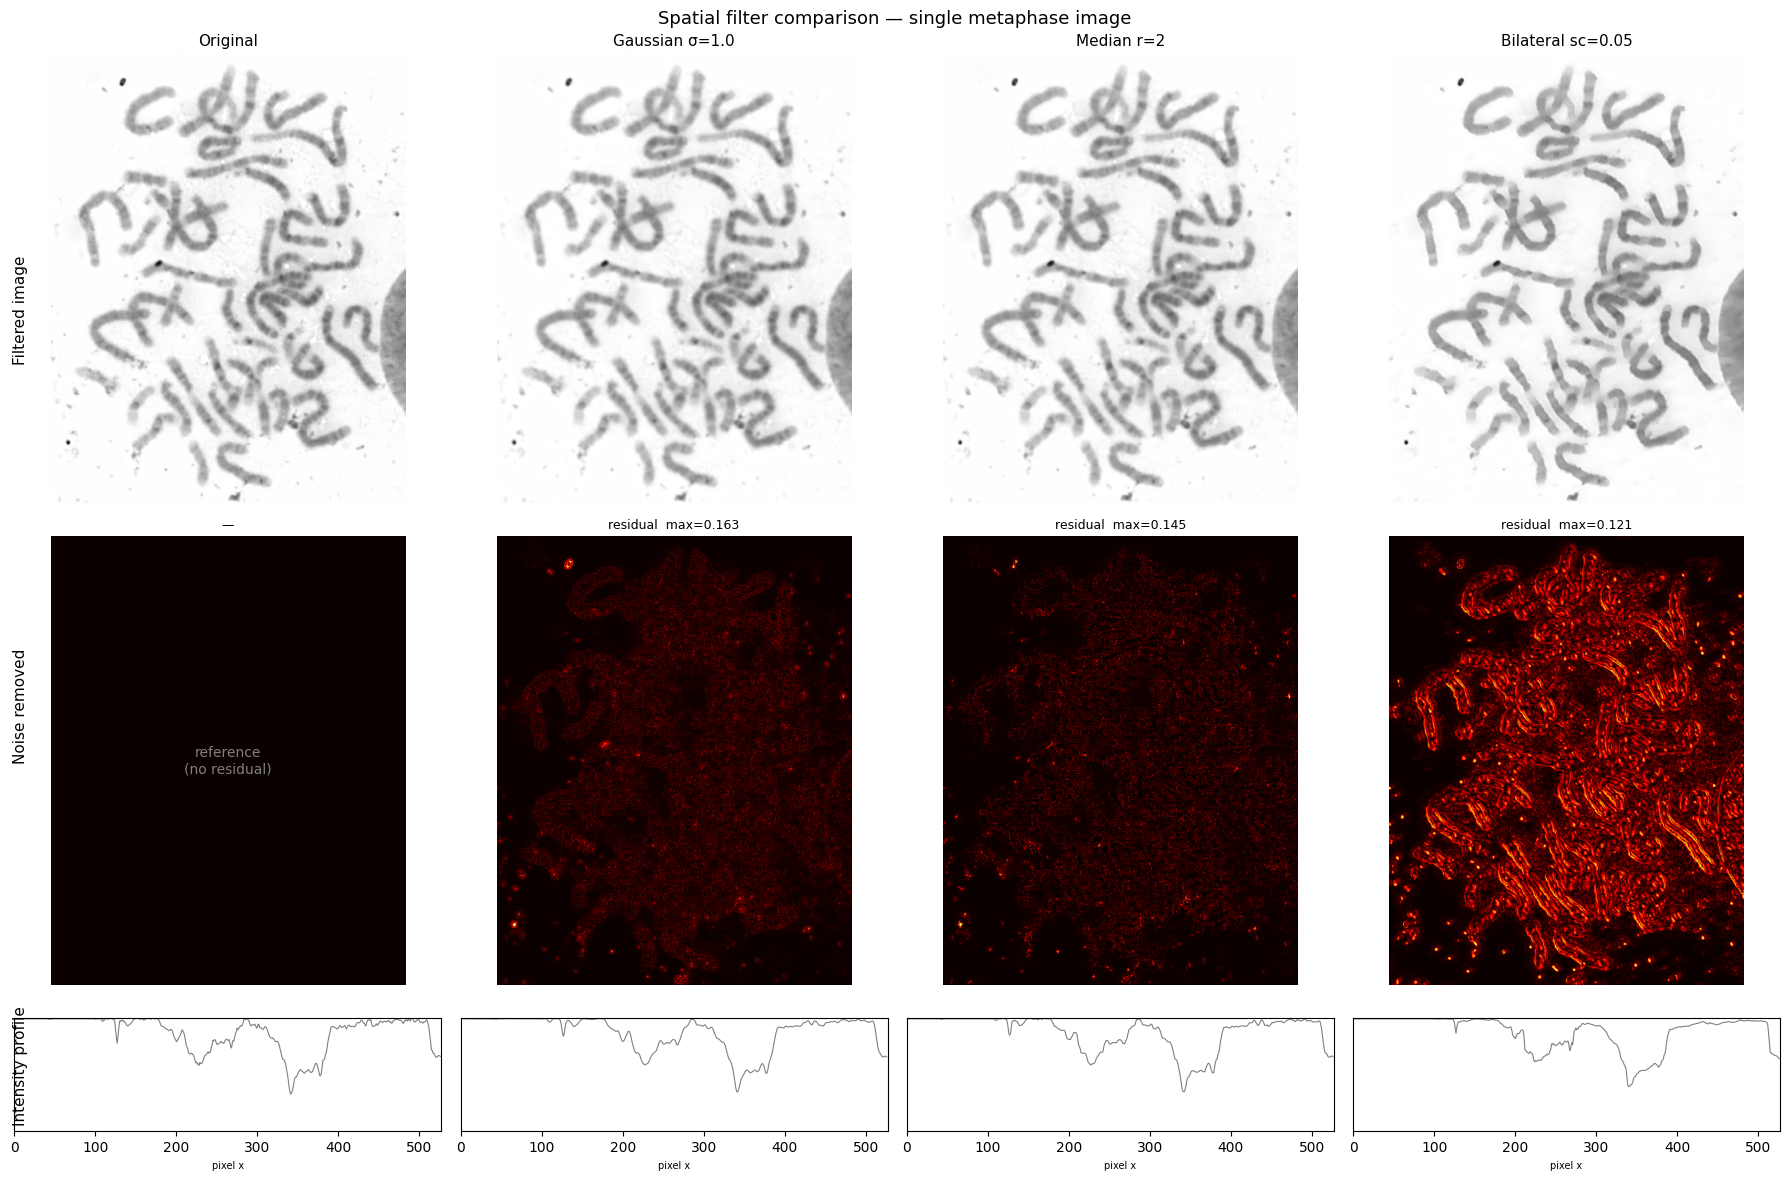

In [ ]:

titles  = ["Original", f"Gaussian σ={GAUSS_SIGMA}", 
           f"Median r={MEDIAN_RADIUS}", f"Bilateral sc={BILATERAL_SC}"]
filtered = [sample, gauss, med, bilat]

fig, axes = plt.subplots(3, 4, figsize=(18, 12),
                         gridspec_kw={"height_ratios": [4, 4, 1]})

for col, (title, fimg) in enumerate(zip(titles, filtered)):

    axes[0, col].imshow(fimg, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(title, fontsize=11)
    axes[0, col].axis("off")

    residual = np.abs(sample - fimg)
    axes[1, col].imshow(residual, cmap="hot",
                        vmin=0, vmax=residual.max() if col > 0 else 0.01)
    axes[1, col].set_title(
        "—" if col == 0 else f"residual  max={residual.max():.3f}",
        fontsize=9
    )
    axes[1, col].axis("off")


    mid = fimg.shape[0] // 2
    axes[2, col].plot(fimg[mid, :], linewidth=0.8, color="gray")
    axes[2, col].set_xlim(0, fimg.shape[1])
    axes[2, col].set_ylim(0, 1)
    axes[2, col].set_yticks([])
    axes[2, col].set_xlabel("pixel x", fontsize=7)

axes[1, 0].text(0.5, 0.5, "reference\n(no residual)", ha="center", va="center",
                transform=axes[1, 0].transAxes, fontsize=10, color="gray")

fig.text(0.01, 0.73, "Filtered image",   va="center", rotation=90, fontsize=11)
fig.text(0.01, 0.40, "Noise removed",    va="center", rotation=90, fontsize=11)
fig.text(0.01, 0.10, "Intensity profile",va="center", rotation=90, fontsize=11)

plt.suptitle("Spatial filter comparison — single metaphase image", fontsize=13)
plt.tight_layout()
plt.show()

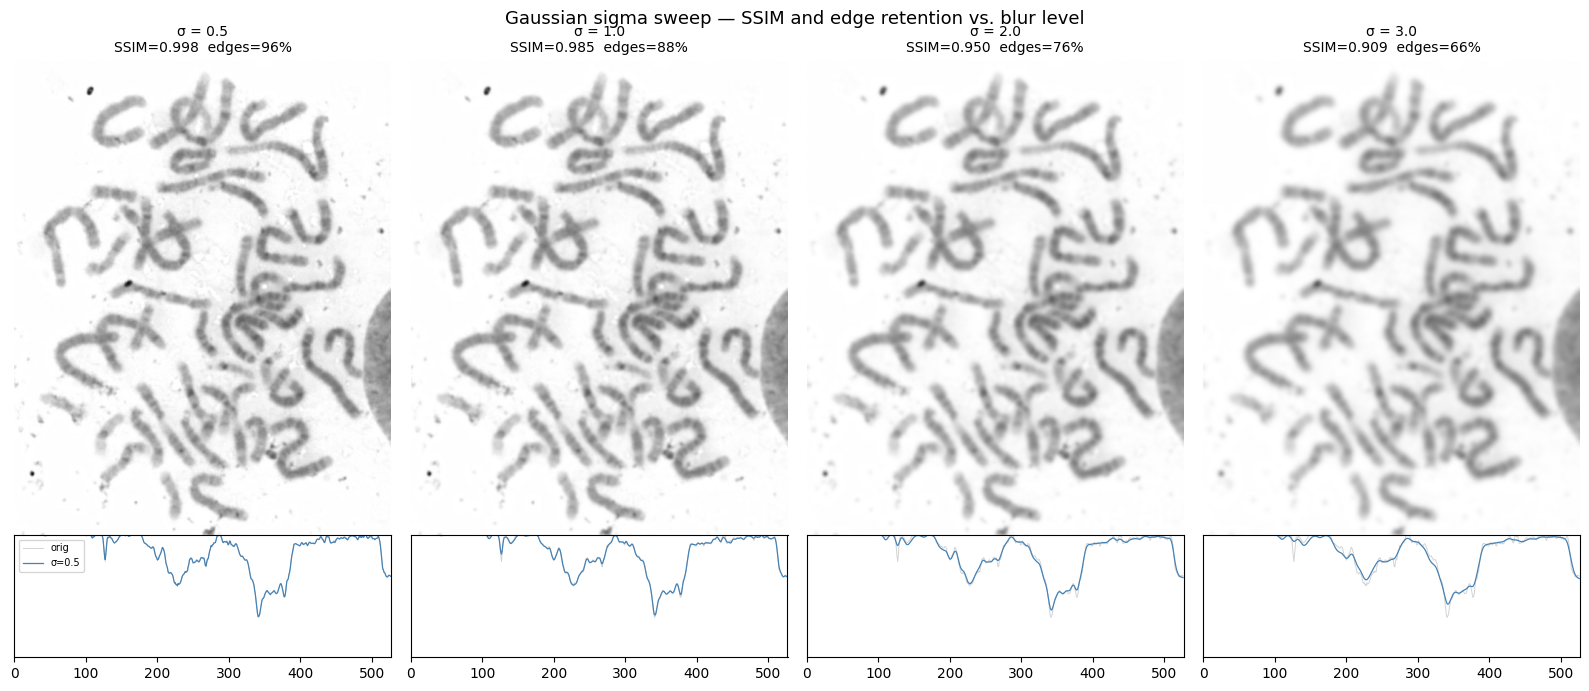

Recommended: σ = 1.0  (good noise removal, >90% edge retention)


In [ ]:

sigmas = [0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(2, len(sigmas), figsize=(16, 7),
                         gridspec_kw={"height_ratios": [4, 1]})

for col, s in enumerate(sigmas):
    g = gaussian(sample, sigma=s)
    ssim_val  = ssim(sample, g, data_range=1.0)
    edge_ret  = sobel(g).mean() / edge_orig

    axes[0, col].imshow(g, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(
        f"σ = {s}\nSSIM={ssim_val:.3f}  edges={edge_ret:.0%}",
        fontsize=10
    )
    axes[0, col].axis("off")

    mid = g.shape[0] // 2
    axes[1, col].plot(sample[mid, :], linewidth=0.7, color="lightgray", label="orig")
    axes[1, col].plot(g[mid, :],      linewidth=0.9, color="steelblue", label=f"σ={s}")
    axes[1, col].set_xlim(0, g.shape[1])
    axes[1, col].set_ylim(0, 1)
    axes[1, col].set_yticks([])
    if col == 0:
        axes[1, col].legend(fontsize=7)

plt.suptitle("Gaussian sigma sweep — SSIM and edge retention vs. blur level",
             fontsize=13)
plt.tight_layout()
plt.show()


Filtered 100 images  (Gaussian σ=1.0)
dtype : float64  range : 0.092–1.000


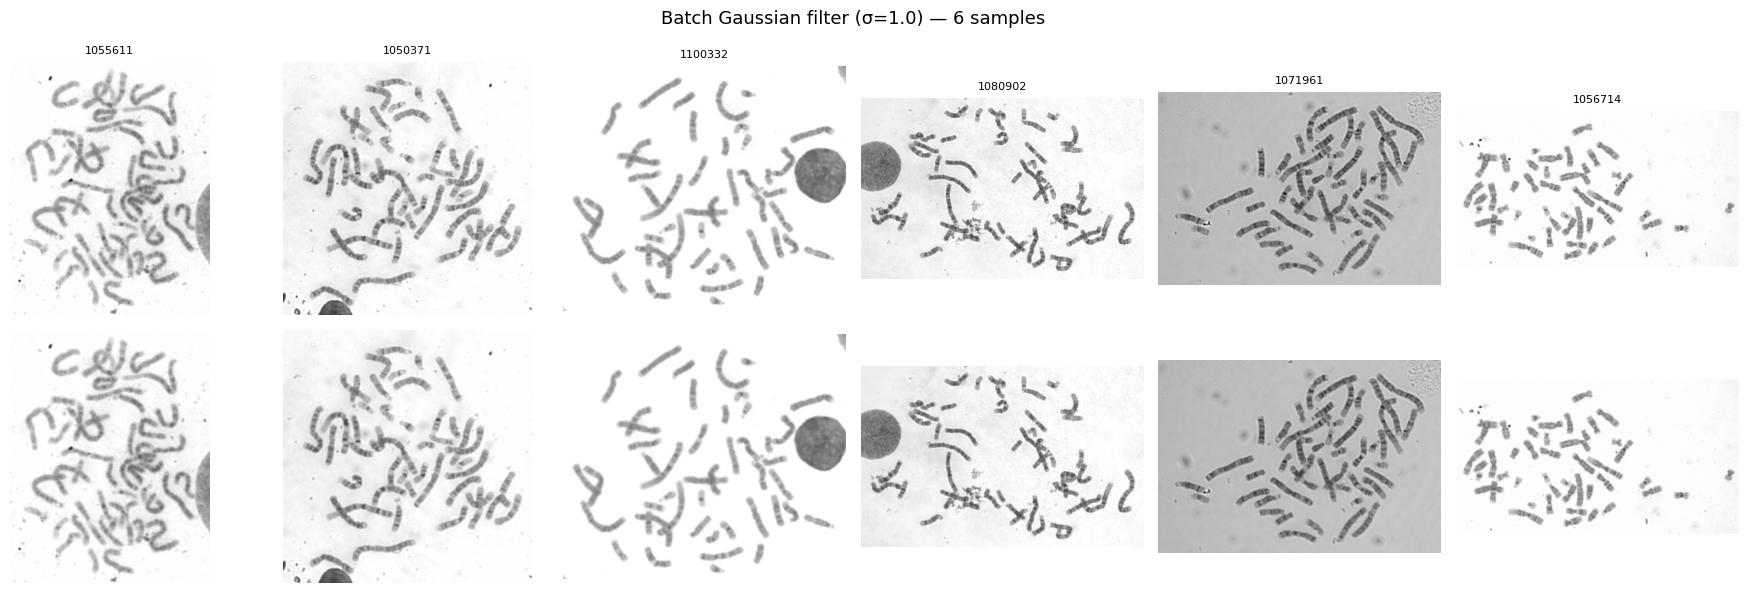

In [ ]:
filtered_images = [gaussian(img, sigma=GAUSS_SIGMA) for img in work_images]

print(f"Filtered {len(filtered_images)} images  (Gaussian σ={GAUSS_SIGMA})")
print(f"dtype : {filtered_images[0].dtype}  "
      f"range : {filtered_images[0].min():.3f}–{filtered_images[0].max():.3f}")


fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col in range(6):
    axes[0, col].imshow(work_images[col],    cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(img_24[col].stem, fontsize=8)
    axes[0, col].axis("off")
    axes[1, col].imshow(filtered_images[col], cmap="gray", vmin=0, vmax=1)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("input",    fontsize=10)
axes[1, 0].set_ylabel("filtered", fontsize=10)
plt.suptitle(f"Batch Gaussian filter (σ={GAUSS_SIGMA}) — 6 samples", fontsize=13)
plt.tight_layout()
plt.show()

## 1.3 Edge / Gradient Analysis

From lecture: **point → line → edge** detection hierarchy.

| Detector | Order | What it finds | Key property |
|----------|-------|--------------|--------------|
| **Roberts Cross** | 1st (diagonal) | Fine edges, noisy | Smallest 2×2 kernel |
| **Prewitt** | 1st | Edges (uniform weights) | Simple gradient estimate |
| **Sobel** | 1st | Edges (distance-weighted) | Better noise suppression than Prewitt |
| **Laplacian / LoG** | 2nd | Zero-crossings at edges; blobs | Isotropic; sensitive to noise |
| **Canny** | Multi-stage | Clean, thin edges | Gaussian → gradient → NMS → hysteresis |

For chromosome images the goal is to delineate **chromosome boundaries** cleanly — Canny on the smoothed/enhanced image gives the best result for downstream segmentation.

Input: `filtered_images` (Gaussian-smoothed).

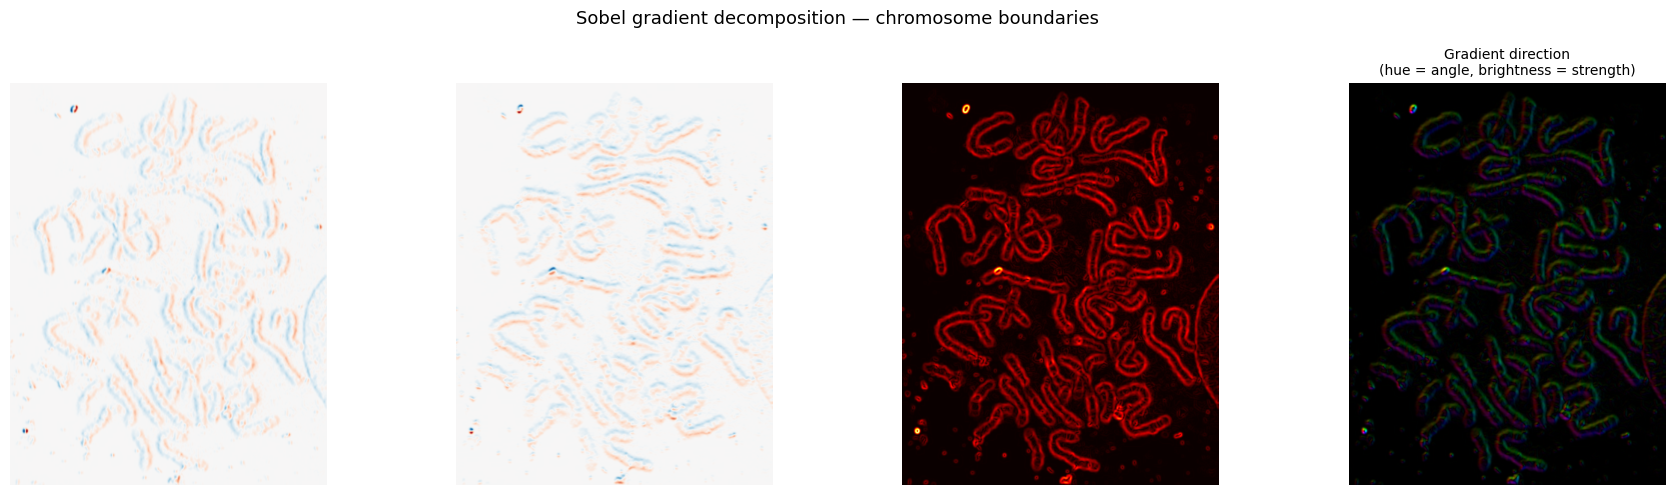

Gradient magnitude — mean: 0.0270  max: 0.4817


In [36]:
from skimage.filters import sobel_h, sobel_v, sobel, laplace
from skimage.feature import canny

# Work on the first filtered image
fsample = filtered_images[0]


Gx  = sobel_v(fsample)           
Gy  = sobel_h(fsample)           
Gmag = np.hypot(Gx, Gy)          
Gdir = np.arctan2(Gy, Gx)        

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(Gx,   cmap="RdBu_r", vmin=-Gmag.max(), vmax=Gmag.max())


axes[1].imshow(Gy,   cmap="RdBu_r", vmin=-Gmag.max(), vmax=Gmag.max())


axes[2].imshow(Gmag, cmap="hot")


H = (Gdir + np.pi) / (2 * np.pi)          
V = Gmag / Gmag.max()                 
S = np.ones_like(H)
hsv = np.stack([H, S, V], axis=-1)
from matplotlib.colors import hsv_to_rgb
axes[3].imshow(hsv_to_rgb(hsv))
axes[3].set_title("Gradient direction\n(hue = angle, brightness = strength)", fontsize=10)

for ax in axes:
    ax.axis("off")

plt.suptitle("Sobel gradient decomposition — chromosome boundaries", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Gradient magnitude — mean: {Gmag.mean():.4f}  max: {Gmag.max():.4f}")

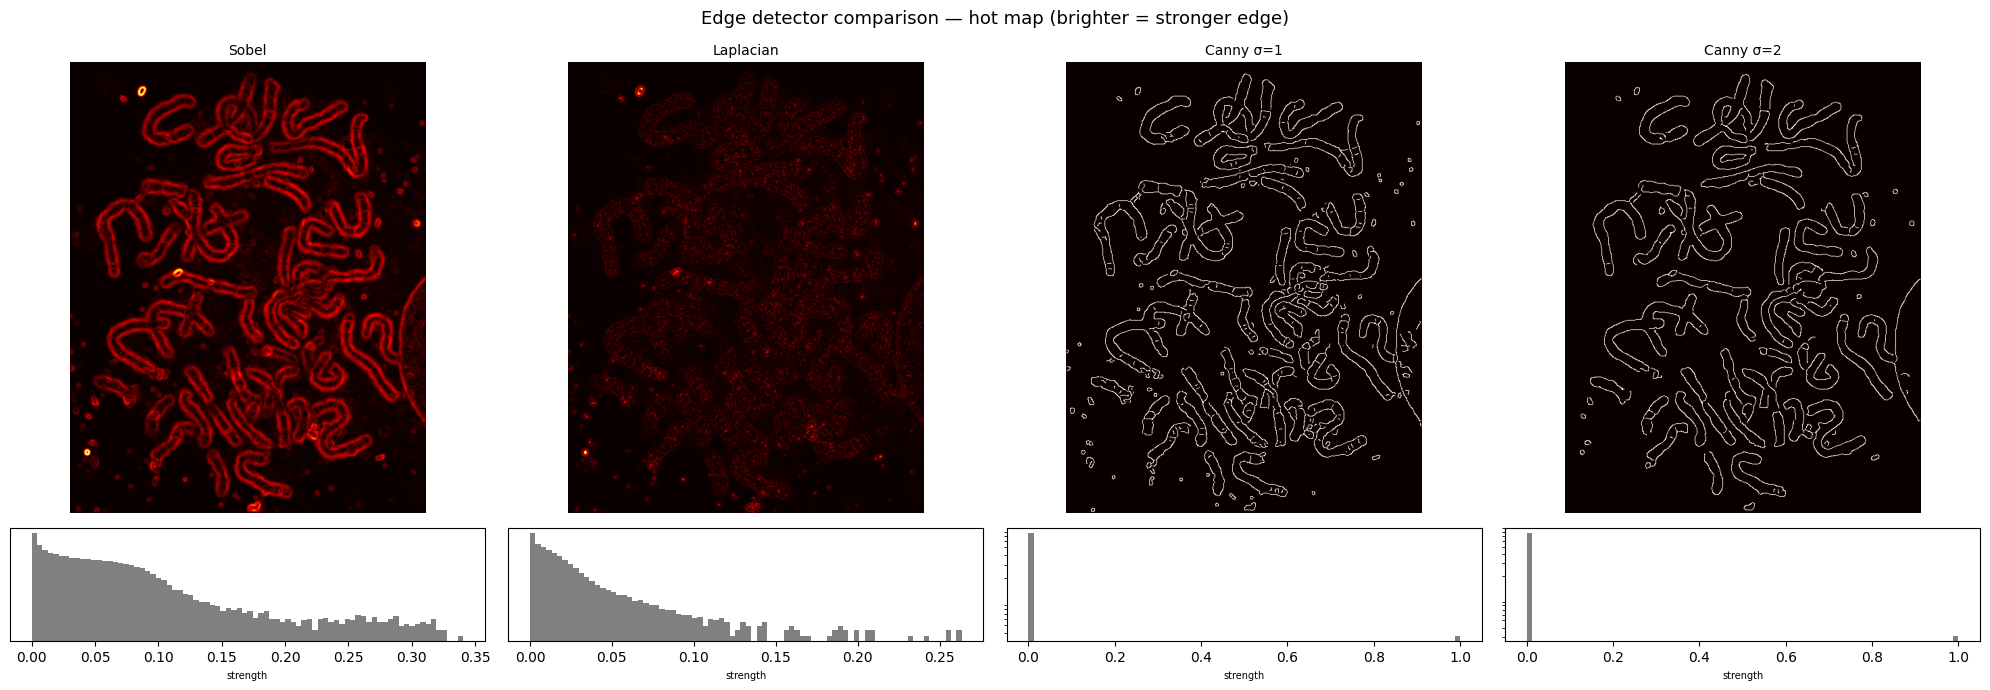

In [37]:
# ── Multi-operator edge map comparison ───────────────────────────────────────
edge_maps = {
    "Sobel"         : sobel(fsample),
    "Laplacian"     : np.abs(laplace(fsample)),
    "Canny σ=1"     : canny(fsample, sigma=1.0).astype(float),
    "Canny σ=2"     : canny(fsample, sigma=2.0).astype(float),
}

fig, axes = plt.subplots(2, len(edge_maps), figsize=(20, 7),
                         gridspec_kw={"height_ratios": [4, 1]})

for col, (name, emap) in enumerate(edge_maps.items()):
  
    disp = emap / emap.max() if emap.max() > 0 else emap

    axes[0, col].imshow(disp, cmap="hot")
    axes[0, col].set_title(name, fontsize=10)
    axes[0, col].axis("off")

   
    axes[1, col].hist(emap.ravel(), bins=80, color="gray", density=True,
                      log=True)  
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("strength", fontsize=7)

plt.suptitle("Edge detector comparison — hot map (brighter = stronger edge)",
             fontsize=13)
plt.tight_layout()
plt.show()

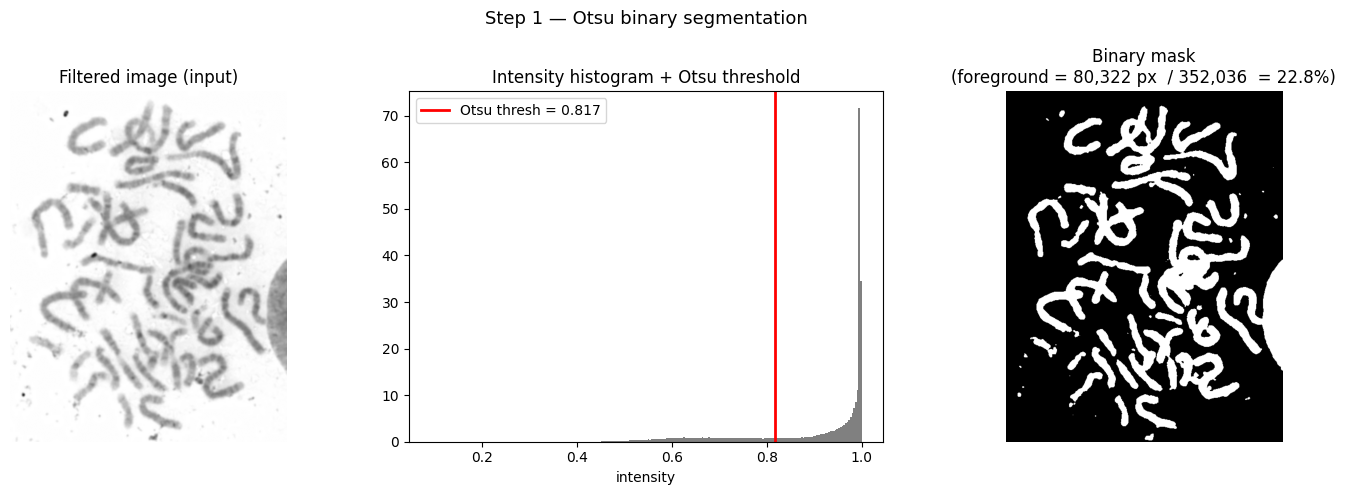

In [ ]:
from skimage.filters import threshold_otsu
from skimage import morphology as morph
from scipy.ndimage import binary_fill_holes


fsample = filtered_images[0]
thresh  = threshold_otsu(fsample)
binary  = fsample < thresh         

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Filtered image (input)")
axes[0].axis("off")

axes[1].hist(fsample.ravel(), bins=256, color="gray", density=True)
axes[1].axvline(thresh, color="red", linewidth=2, label=f"Otsu thresh = {thresh:.3f}")
axes[1].set_title("Intensity histogram + Otsu threshold")
axes[1].set_xlabel("intensity")
axes[1].legend()

axes[2].imshow(binary, cmap="gray")
axes[2].set_title(f"Binary mask\n(foreground = {binary.sum():,} px  "
                  f"/ {binary.size:,}  = {binary.mean():.1%})")
axes[2].axis("off")

plt.suptitle("Step 1 — Otsu binary segmentation", fontsize=13)
plt.tight_layout()
plt.show()


C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1365674491.py:7: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  f"square({SE_RADIUS*2+1})":    square(SE_RADIUS * 2 + 1),


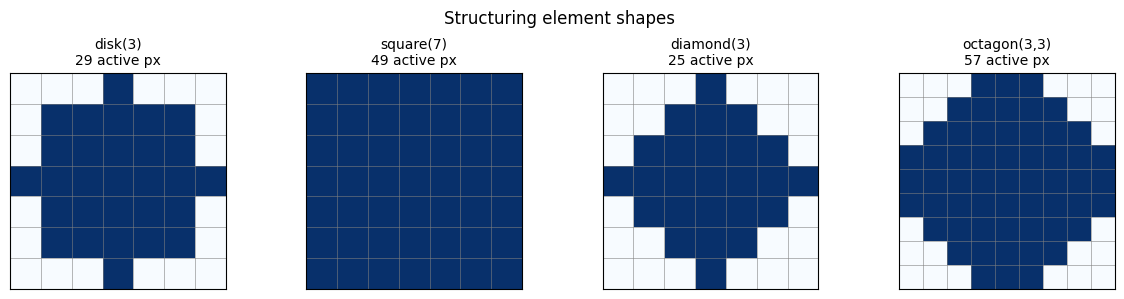

In [40]:

from skimage.morphology import disk, square, diamond, octagon, star

SE_RADIUS = 3  

ses = {
    f"disk({SE_RADIUS})":          disk(SE_RADIUS),
    f"square({SE_RADIUS*2+1})":    square(SE_RADIUS * 2 + 1),
    f"diamond({SE_RADIUS})":       diamond(SE_RADIUS),
    f"octagon({SE_RADIUS},{SE_RADIUS})": octagon(SE_RADIUS, SE_RADIUS),
}

fig, axes = plt.subplots(1, len(ses), figsize=(12, 3))
for ax, (name, se) in zip(axes, ses.items()):
    ax.imshow(se, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
    for x in range(se.shape[1] + 1):
        ax.axvline(x - 0.5, color="gray", linewidth=0.4)
    for y in range(se.shape[0] + 1):
        ax.axhline(y - 0.5, color="gray", linewidth=0.4)
    ax.set_title(f"{name}\n{se.sum()} active px", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Structuring element shapes ")
plt.tight_layout()
plt.show()

SE = disk(3)

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:2: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  eroded  = morph.binary_erosion( binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:3: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = morph.binary_dilation(binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:4: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  opened  = morph.binary_opening( binary, SE)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\1733964433.py:5: Future

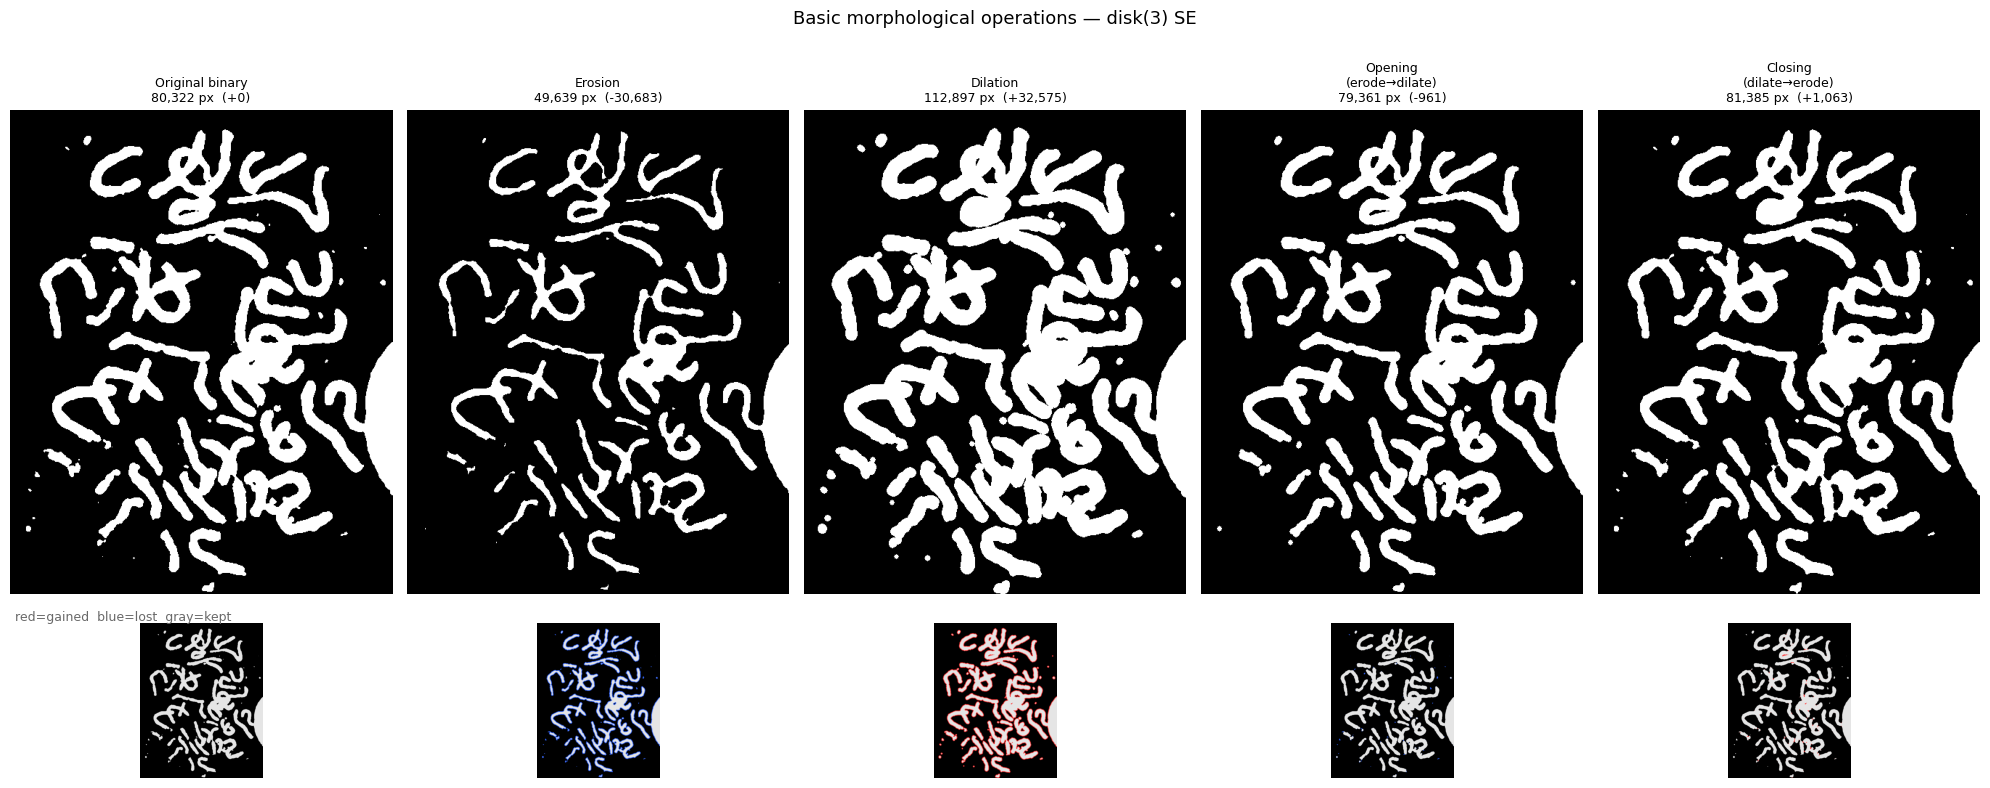

In [ ]:
eroded  = morph.binary_erosion( binary, SE)
dilated = morph.binary_dilation(binary, SE)
opened  = morph.binary_opening( binary, SE)
closed  = morph.binary_closing( binary, SE)

ops = {
    "Original binary" : binary,
    "Erosion"         : eroded,
    "Dilation"        : dilated,
    "Opening\n(erode→dilate)": opened,
    "Closing\n(dilate→erode)": closed,
}

fig, axes = plt.subplots(2, len(ops), figsize=(20, 8),
                         gridspec_kw={"height_ratios": [4, 1]})

ref_px = binary.sum()
for col, (name, mask) in enumerate(ops.items()):
    axes[0, col].imshow(mask, cmap="gray")
    delta = mask.sum() - ref_px
    sign  = "+" if delta >= 0 else ""
    axes[0, col].set_title(
        f"{name}\n{mask.sum():,} px  ({sign}{delta:,})",
        fontsize=9
    )
    axes[0, col].axis("off")

   
    diff = np.zeros((*binary.shape, 3))
    diff[mask  & ~binary] = [1, 0.2, 0.2]   
    diff[~mask &  binary] = [0.2, 0.4, 1.0] 
    diff[mask  &  binary] = [0.9, 0.9, 0.9] 
    axes[1, col].imshow(diff)
    axes[1, col].axis("off")

fig.text(0.01, 0.22, "red=gained  blue=lost  gray=kept",
         va="center", fontsize=9, color="dimgray")
plt.suptitle(f"Basic morphological operations — disk(3) SE", fontsize=13)
plt.tight_layout()
plt.show()

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:7: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  grad      = morph.binary_dilation(binary, SE).astype(int) \
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:8: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  - morph.binary_erosion( binary, SE).astype(int)    # morphological gradient (boundary)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\288530039.py:10: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the 

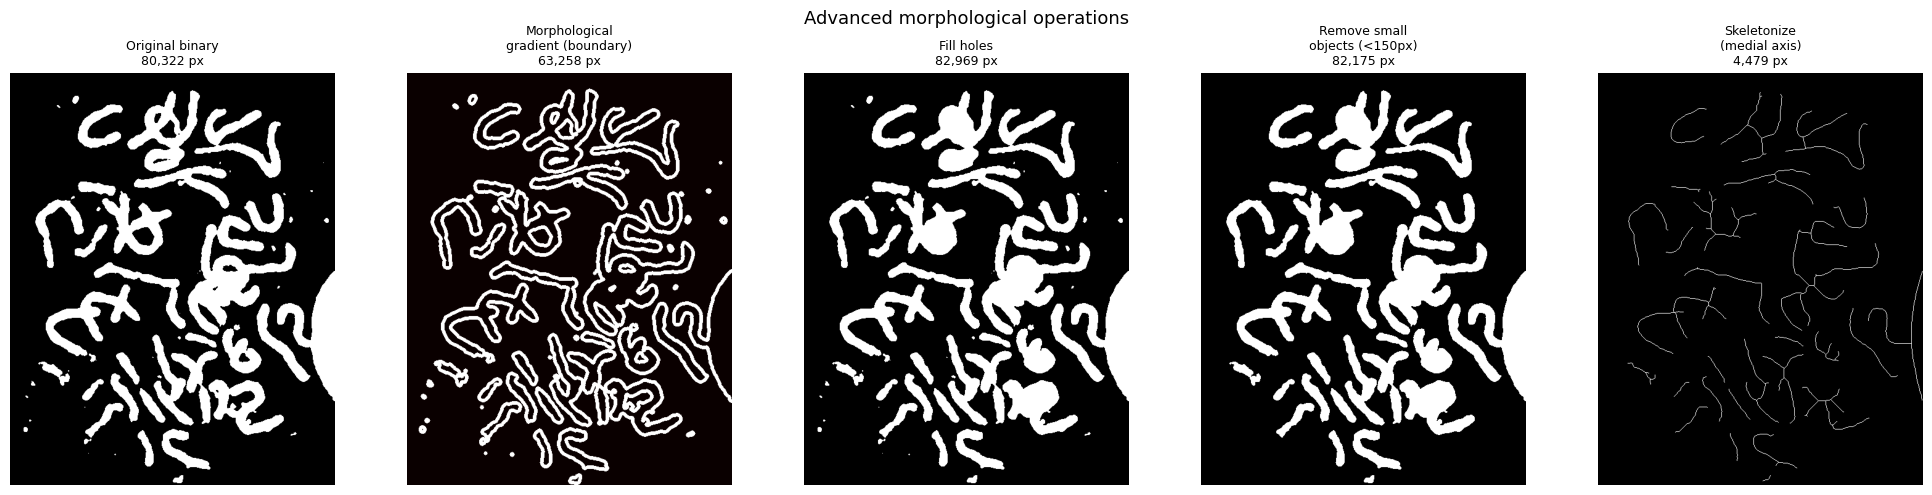

Skeleton branches (connected components) : 28
Total skeleton pixels                    : 4479


In [ ]:

MIN_OBJ_SIZE   = 150   
MIN_HOLE_SIZE  = 200   


grad      = morph.binary_dilation(binary, SE).astype(int) \
           - morph.binary_erosion( binary, SE).astype(int)   
filled    = binary_fill_holes(binary)                        
cleaned   = morph.remove_small_objects(filled, min_size=MIN_OBJ_SIZE)  
skeleton  = morph.skeletonize(cleaned)                     

adv_ops = {
    "Original binary"    : binary,
    "Morphological\ngradient (boundary)": grad.astype(bool),
    "Fill holes"         : filled,
    f"Remove small\nobjects (<{MIN_OBJ_SIZE}px)": cleaned,
    "Skeletonize\n(medial axis)": skeleton,
}

fig, axes = plt.subplots(1, len(adv_ops), figsize=(20, 5))
cmaps = ["gray", "hot", "gray", "gray", "gray"]

for ax, (name, mask), cmap in zip(axes, adv_ops.items(), cmaps):
    ax.imshow(mask, cmap=cmap)
    ax.set_title(f"{name}\n{mask.sum():,} px", )
    ax.axis("off")

plt.suptitle("Advanced morphological operations", )
plt.tight_layout()
plt.show()


from skimage.measure import label
skel_labels = label(skeleton)
print(f"Skeleton branches (connected components) : {skel_labels.max()}")
print(f"Total skeleton pixels                    : {skeleton.sum()}")

C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\545970897.py:9: FutureWarning: `binary_opening` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.opening` instead.
  mask = morph.binary_opening(mask, se)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\545970897.py:10: FutureWarning: `binary_closing` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.closing` instead.
  mask = morph.binary_closing(mask, se)
C:\Users\ANING\AppData\Local\Temp\ipykernel_56788\545970897.py:11: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morph.remove_small_objects(mask, min

Produced 100 clean binary masks


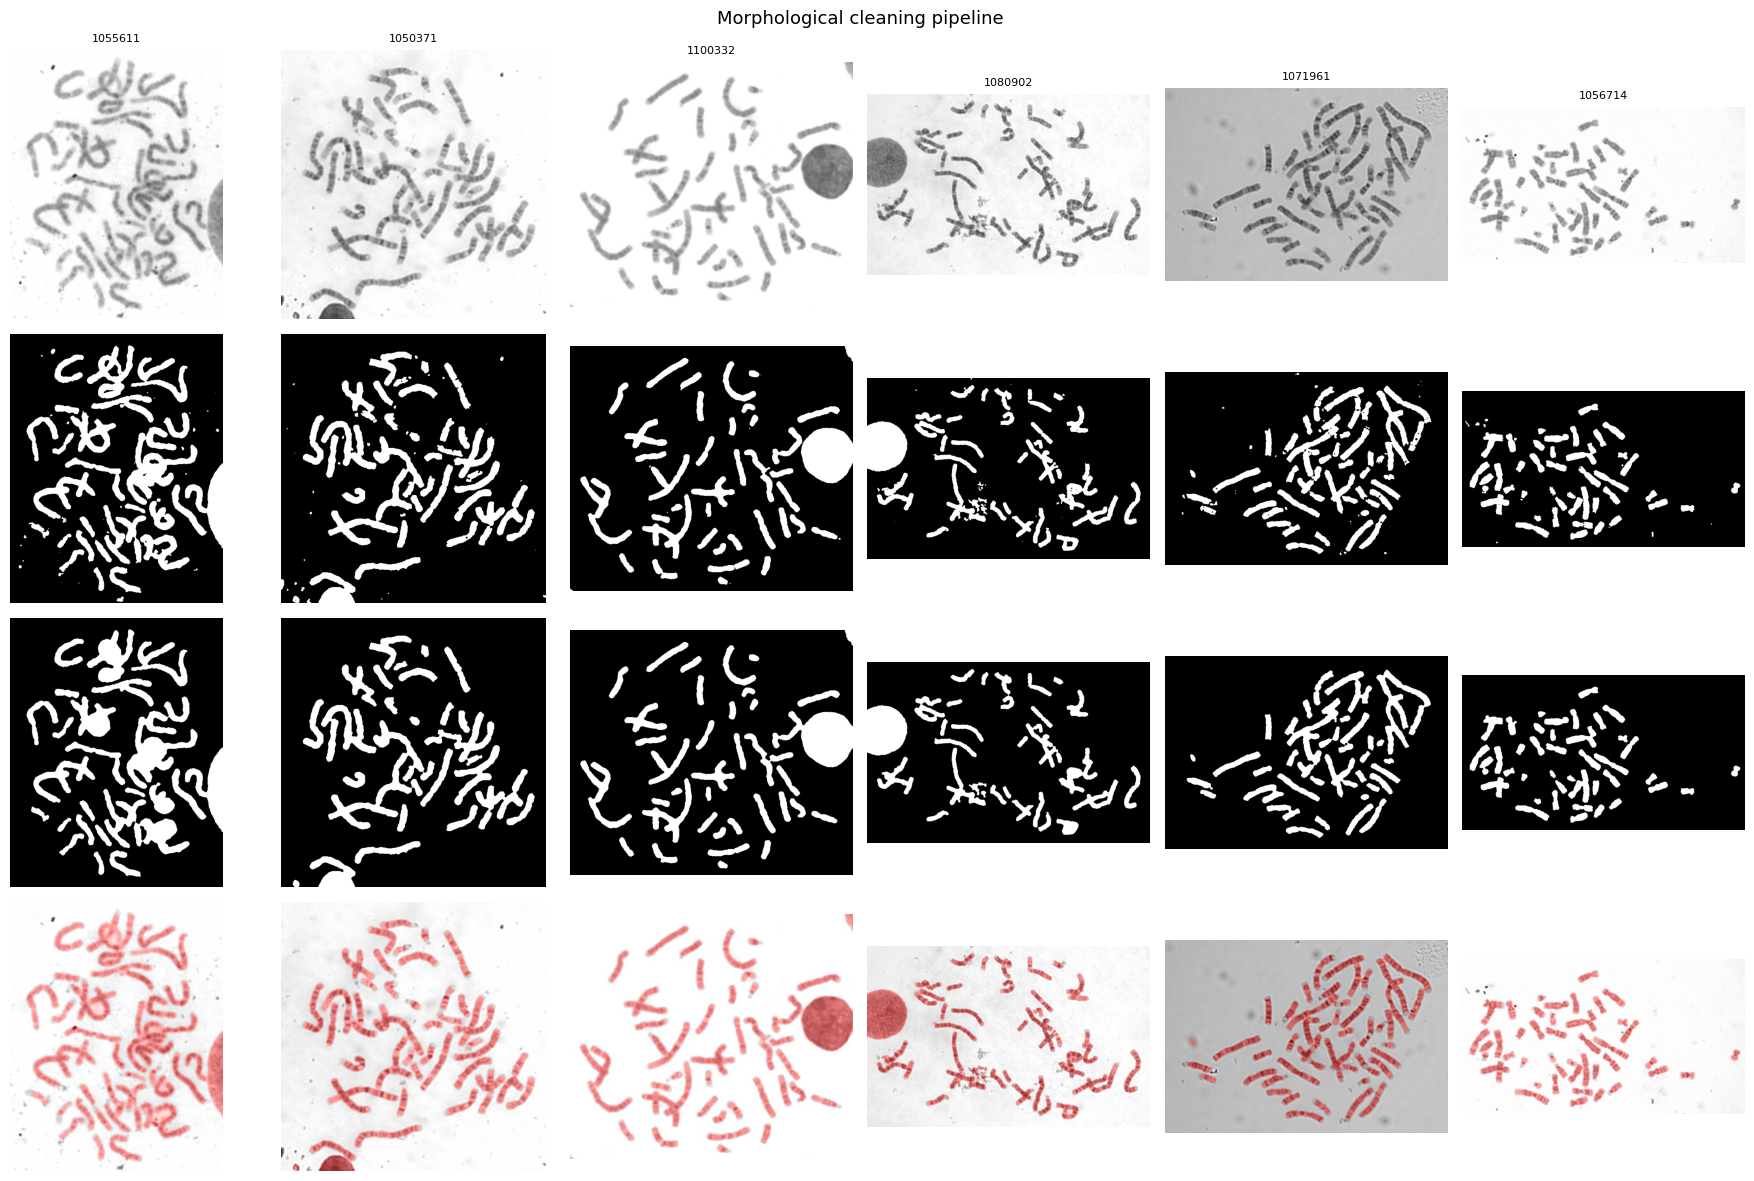

In [42]:

def clean_binary_mask(gray_img,
                      se=disk(3),
                      min_obj=MIN_OBJ_SIZE,
                      min_hole=MIN_HOLE_SIZE):
    
    t    = threshold_otsu(gray_img)
    mask = gray_img < t
    mask = binary_fill_holes(mask)
    mask = morph.binary_opening(mask, se)
    mask = morph.binary_closing(mask, se)
    mask = morph.remove_small_objects(mask, min_size=min_obj)
    return mask

clean_masks = [clean_binary_mask(f) for f in filtered_images]

print(f"Produced {len(clean_masks)} clean binary masks")

fig, axes = plt.subplots(4, 6, figsize=(18, 12))
row_labels = ["Filtered image", "Raw binary (Otsu)", "Cleaned mask", "Overlay"]

for col in range(6):
    fimg   = filtered_images[col]
    raw_b  = fimg < threshold_otsu(fimg)
    clean  = clean_masks[col]

    overlay = np.stack([fimg, fimg, fimg], axis=-1)
    overlay[clean] = np.clip(overlay[clean] + [0.3, -0.1, -0.1], 0, 1)

    for row, (im, cmap) in enumerate([(fimg,    "gray"),
                                       (raw_b,   "gray"),
                                       (clean,   "gray"),
                                       (overlay, None)]):
        ax = axes[row, col]
        if cmap:
            ax.imshow(im, cmap=cmap, vmin=0, vmax=1)
        else:
            ax.imshow(im, vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=9)
        if row == 0:
            ax.set_title(img_24[col].stem, fontsize=8)
        ax.axis("off")

plt.suptitle("Morphological cleaning pipeline", fontsize=13)
plt.tight_layout()
plt.show()

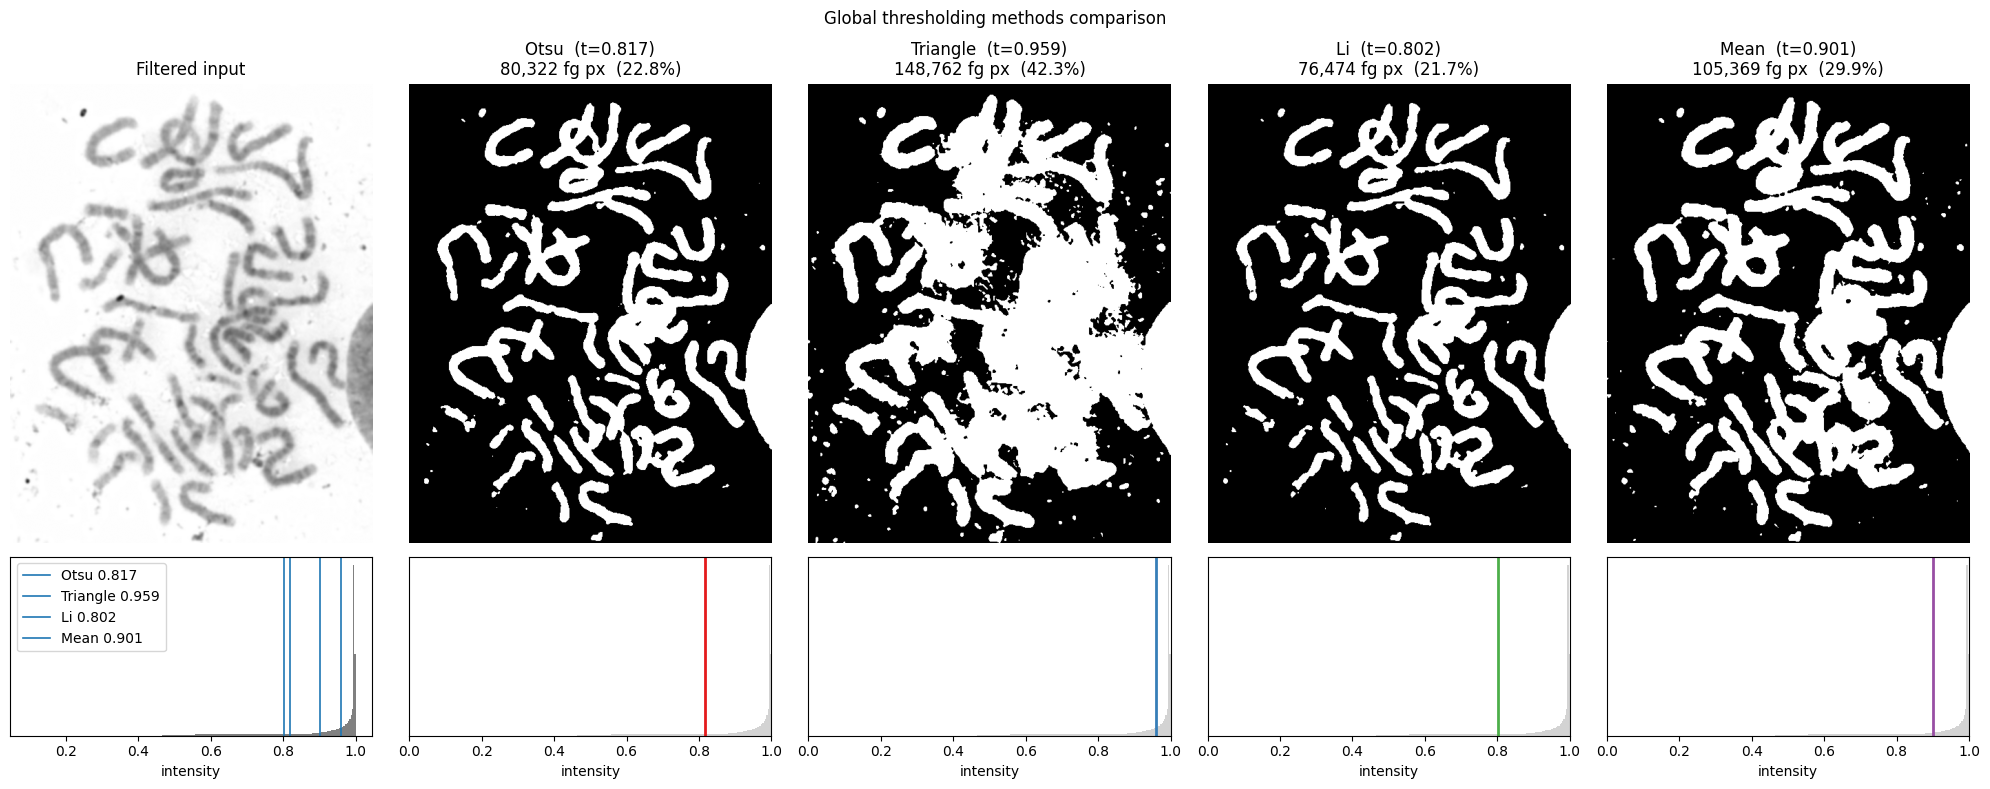

In [41]:
from skimage.filters import (threshold_otsu, threshold_triangle,
                             threshold_li, threshold_mean,
                             threshold_sauvola)
from skimage.filters import threshold_multiotsu


fsample = filtered_images[0]


thresholds = {
    "Otsu"     : threshold_otsu(fsample),
    "Triangle" : threshold_triangle(fsample),
    "Li"       : threshold_li(fsample),
    "Mean"     : threshold_mean(fsample),
}

fig, axes = plt.subplots(2, len(thresholds) + 1, figsize=(20, 8),
                         gridspec_kw={"height_ratios": [3, 1]})


axes[0, 0].imshow(fsample, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Filtered input", )
axes[0, 0].axis("off")
axes[1, 0].hist(fsample.ravel(), bins=256, color="gray", density=True)
axes[1, 0].set_xlabel("intensity")
axes[1, 0].set_yticks([])
for name, t in thresholds.items():
    axes[1, 0].axvline(t, linewidth=1.2, label=f"{name} {t:.3f}")
axes[1, 0].legend()


colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3"]
for col, (name, t) in enumerate(thresholds.items(), start=1):
    mask = fsample < t     
    axes[0, col].imshow(mask, cmap="gray")
    axes[0, col].set_title(f"{name}  (t={t:.3f})\n{mask.sum():,} fg px  "
                           f"({mask.mean():.1%})")
    axes[0, col].axis("off")

    axes[1, col].hist(fsample.ravel(), bins=256, color="lightgray", density=True)
    axes[1, col].axvline(t, color=colors[col - 1], linewidth=2)
    axes[1, col].set_xlim(0, 1)
    axes[1, col].set_yticks([])
    axes[1, col].set_xlabel("intensity")

plt.suptitle("Global thresholding methods comparison",)
plt.tight_layout()
plt.show()